In [2]:
import sys
print(sys.executable)



C:\Users\Odynaca\anaconda3\envs\fraud_env\python.exe


In [3]:
import sys
print(sys.executable)


C:\Users\Odynaca\anaconda3\envs\fraud_env\python.exe


In [1]:
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import shap


C:\Users\Odynaca\anaconda3\envs\fraud_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#CREATE SYTHETIC DATASET
n = 2000  # number of synthetic claims

df = pd.DataFrame({
    "bank_details_changed_within_1_day": np.random.binomial(1, 0.1, n),
    "id_doc_is_acceptable": np.random.binomial(1, 0.85, n),
    "employment_mismatch_with_searchlight": np.random.binomial(1, 0.05, n),
    "attends_different_jobcentre_than_residence": np.random.binomial(1, 0.03, n),

    "child_docs_unverifiable_type": np.random.binomial(1, 0.08, n),
    "det_document_result_fake": np.random.binomial(1, 0.02, n),
    "child_benefit_inconsistency": np.random.binomial(1, 0.05, n),

    "new_tenancy_date_inconsistent": np.random.binomial(1, 0.07, n),
    "rent_mismatch_with_previous": np.random.binomial(1, 0.06, n),
    "no_proof_of_address_long_term": np.random.binomial(1, 0.1, n),
    "landlord_is_family_not_declared": np.random.binomial(1, 0.03, n),
    "declared_rent_above_area_band": np.random.binomial(1, 0.04, n),
    "num_rooms_claimed_inconsistent": np.random.binomial(1, 0.02, n),

    "childcare_claimed_while_not_working": np.random.binomial(1, 0.05, n),
    "childcare_meal_cost_claimed_on_tax_free": np.random.binomial(1, 0.03, n),
    "no_valid_childcare_evidence": np.random.binomial(1, 0.07, n),

    "advance_then_close_claim_pattern": np.random.binomial(1, 0.03, n)
})


In [3]:

#CREATE CATEGORICAL FEATURES

id_doc_types = ["passport", "driving_licence", "residence_permit", 
                "nhs_letter", "work_id", "none"]

df["id_doc_type"] = np.random.choice(id_doc_types, size=n, 
                                     p=[0.35, 0.25, 0.10, 0.15, 0.10, 0.05])

landlord_types = ["private", "housing_association", "family", "unknown"]

df["landlord_type"] = np.random.choice(landlord_types, size=n, 
                                       p=[0.60, 0.20, 0.10, 0.10])

childcare_docs = ["invoice", "bank_statement", "handwritten_note", "none"]

df["childcare_docs_type"] = np.random.choice(childcare_docs, size=n, 
                                             p=[0.50, 0.20, 0.20, 0.10])

child_docs = ["birth_certificate", "passport", "school_letter", "nhs_letter", "none"]

df["child_docs_type"] = np.random.choice(child_docs, size=n, 
                                         p=[0.40, 0.10, 0.25, 0.20, 0.05])

employment_sectors = ["retail", "hospitality", "care", "construction", 
                      "office_admin", "warehouse", "unknown"]

df["declared_employment_sector"] = np.random.choice(employment_sectors, size=n)

jobcentres = ["Birmingham_City", "Selly_Oak", "Sparkhill", "Wolverhampton", "Coventry"]

df["jobcentre_of_residence"] = np.random.choice(jobcentres, size=n)
df["jobcentre_attended"] = np.random.choice(jobcentres, size=n)

tenancy_types = ["standard_AST", "handwritten", "unsigned", "digital_pdf"]

df["tenancy_agreement_type"] = np.random.choice(tenancy_types, size=n, 
                                                p=[0.60, 0.10, 0.10, 0.20])


In [4]:
df.head()


,bank_details_changed_within_1_day,id_doc_is_acceptable,employment_mismatch_with_searchlight,attends_different_jobcentre_than_residence,child_docs_unverifiable_type,det_document_result_fake,child_benefit_inconsistency,new_tenancy_date_inconsistent,rent_mismatch_with_previous,no_proof_of_address_long_term,...,no_valid_childcare_evidence,advance_then_close_claim_pattern,id_doc_type,landlord_type,childcare_docs_type,child_docs_type,declared_employment_sector,jobcentre_of_residence,jobcentre_attended,tenancy_agreement_type
0,1,1,0,0,0,0,0,0,0,0,...,0,0,work_id,private,invoice,passport,unknown,Sparkhill,Selly_Oak,digital_pdf
1,0,1,0,0,0,0,1,1,0,0,...,1,0,nhs_letter,unknown,invoice,school_letter,warehouse,Selly_Oak,Coventry,digital_pdf
2,0,1,0,0,0,0,0,0,1,0,...,0,0,residence_permit,private,bank_statement,birth_certificate,office_admin,Sparkhill,Selly_Oak,standard_AST
3,1,0,1,0,0,0,0,0,0,0,...,0,0,passport,private,bank_statement,birth_certificate,retail,Birmingham_City,Sparkhill,digital_pdf
4,0,0,0,0,0,0,0,0,0,0,...,0,0,passport,private,invoice,school_letter,hospitality,Wolverhampton,Birmingham_City,standard_AST


In [5]:
df.shape


(2000, 25)

In [6]:
df.columns

Index(['bank_details_changed_within_1_day', 'id_doc_is_acceptable',
       'employment_mismatch_with_searchlight',
       'attends_different_jobcentre_than_residence',
       'child_docs_unverifiable_type', 'det_document_result_fake',
       'child_benefit_inconsistency', 'new_tenancy_date_inconsistent',
       'rent_mismatch_with_previous', 'no_proof_of_address_long_term',
       'landlord_is_family_not_declared', 'declared_rent_above_area_band',
       'num_rooms_claimed_inconsistent', 'childcare_claimed_while_not_working',
       'childcare_meal_cost_claimed_on_tax_free',
       'no_valid_childcare_evidence', 'advance_then_close_claim_pattern',
       'id_doc_type', 'landlord_type', 'childcare_docs_type',
       'child_docs_type', 'declared_employment_sector',
       'jobcentre_of_residence', 'jobcentre_attended',
       'tenancy_agreement_type'],
      dtype='object')

In [7]:
#ID doc type
df["id_doc_type"].value_counts(normalize=True)

id_doc_type
passport            0.3490
driving_licence     0.2575
nhs_letter          0.1390
work_id             0.1055
residence_permit    0.0950
none                0.0540
Name: proportion, dtype: float64

In [8]:
#ID doc type
df["id_doc_type"].value_counts(normalize=True)

id_doc_type
passport            0.3490
driving_licence     0.2575
nhs_letter          0.1390
work_id             0.1055
residence_permit    0.0950
none                0.0540
Name: proportion, dtype: float64

In [9]:
df["jobcentre_of_residence"].value_counts(normalize=True) 

jobcentre_of_residence
Coventry           0.2150
Birmingham_City    0.2040
Selly_Oak          0.1965
Sparkhill          0.1925
Wolverhampton      0.1920
Name: proportion, dtype: float64

In [10]:
#Add the fraud‑scoring function

def label_fraud(row):
    score = 0

    # ---------------------------------------------------------
    # 1. IDENTITY FRAUD PATTERNS (Instance 1)
    # ---------------------------------------------------------

    unacceptable_ids = ["nhs_letter", "work_id", "none"]

    if row.bank_details_changed_within_1_day and row.id_doc_type in unacceptable_ids:
        score += 3

    if row.id_doc_type in unacceptable_ids:
        score += 1

    if row.employment_mismatch_with_searchlight:
        score += 2

    if row.jobcentre_attended != row.jobcentre_of_residence:
        score += 1

    # ---------------------------------------------------------
    # 2. CHILDREN / HOUSEHOLD COMPOSITION FRAUD (Instance 2)
    # ---------------------------------------------------------

    unverifiable_child_docs = ["school_letter", "nhs_letter"]

    if row.child_docs_type in unverifiable_child_docs:
        score += 1

    if row.det_document_result_fake:
        score += 3

    if row.child_benefit_inconsistency:
        score += 2

    # ---------------------------------------------------------
    # 3. HOUSING FRAUD PATTERNS (Instance 3)
    # ---------------------------------------------------------

    if row.new_tenancy_date_inconsistent:
        score += 1

    if row.rent_mismatch_with_previous:
        score += 1

    if row.no_proof_of_address_long_term:
        score += 1

    if row.landlord_type == "family":
        score += 2

    if row.declared_rent_above_area_band:
        score += 2

    if row.num_rooms_claimed_inconsistent:
        score += 1

    suspicious_tenancy_types = ["handwritten", "unsigned"]

    if row.tenancy_agreement_type in suspicious_tenancy_types:
        score += 1

    # ---------------------------------------------------------
    # 4. CHILDCARE FRAUD PATTERNS (Instance 4)
    # ---------------------------------------------------------

    if row.childcare_claimed_while_not_working:
        score += 2

    if row.childcare_meal_cost_claimed_on_tax_free:
        score += 1

    if row.no_valid_childcare_evidence:
        score += 1

    suspicious_childcare_docs = ["handwritten_note", "none"]

    if row.childcare_docs_type in suspicious_childcare_docs:
        score += 1

    # ---------------------------------------------------------
    # 5. ADVANCE THEN CLOSE CLAIM (Instance 5)
    # ---------------------------------------------------------

    if row.advance_then_close_claim_pattern:
        score += 3

    # ---------------------------------------------------------
    # FINAL LABEL
    # ---------------------------------------------------------

    return 1 if score >= 3 else 0


In [11]:
#Apply the function to create the fraud label
df["is_fraudulent"] = df.apply(label_fraud, axis=1)


In [12]:
df["is_fraudulent"].value_counts(normalize=True)


is_fraudulent
1    0.605
0    0.395
Name: proportion, dtype: float64

In [13]:
#Encode categorical features
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.shape


(2000, 50)

In [14]:
#Train your Random Forest model
# Split features and target
X = df_encoded.drop("is_fraudulent", axis=1)
y = df_encoded["is_fraudulent"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.85      0.86       240
           1       0.90      0.92      0.91       360

    accuracy                           0.89       600
   macro avg       0.89      0.89      0.89       600
weighted avg       0.89      0.89      0.89       600



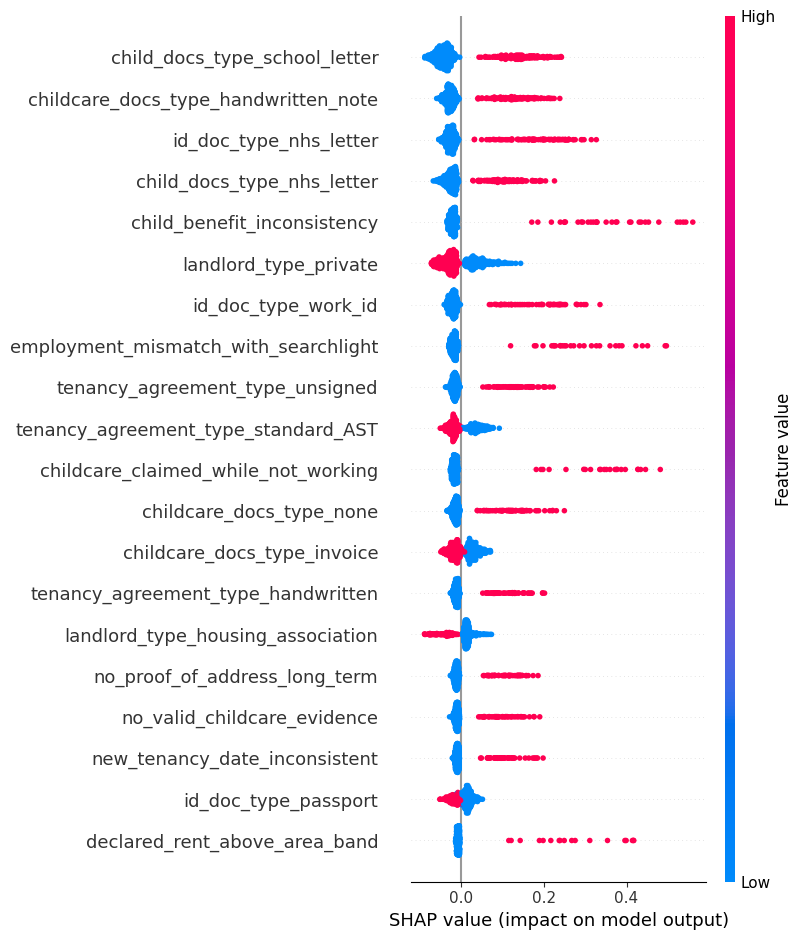

In [15]:
#SHAP Global Explainability

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Extract SHAP values for class 1 (fraud)
sv = shap_values.values[:, :, 1]

shap.summary_plot(sv, X_test)


In [16]:
#local SHAP force plots
shap.initjs()
i = 10
shap.force_plot(
    explainer.expected_value[1],
    sv[i],
    X_test.iloc[i]
)


In [17]:
# Pull genuinely high‑risk case from the model so we can analyse it with a SHAP force plot.
#Step 1 — Get predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]


In [19]:
#Step 2 — Find the index of the highest‑risk claim
highest_risk_index = y_proba.argmax()
highest_risk_index


np.int64(104)

In [21]:
#Step 3 — Generate the SHAP force plot for that case
shap.initjs()

i = highest_risk_index

shap.force_plot(
    explainer.expected_value[1],
    sv[i],
    X_test.iloc[i]
)


In [22]:
#lowest‑risk case
lowest_risk_index = y_proba.argmin()
lowest_risk_index


np.int64(555)

In [23]:
shap.initjs()

i = lowest_risk_index

shap.force_plot(
    explainer.expected_value[1],
    sv[i],
    X_test.iloc[i]
)


In [25]:
#Compare high‑risk vs low‑risk side by side

print("HIGH RISK CASE (index =", highest_risk_index, ")")
display(X_test.iloc[highest_risk_index])

print("\nLOW RISK CASE (index =", lowest_risk_index, ")")
display(X_test.iloc[lowest_risk_index])


HIGH RISK CASE (index = 104 )


bank_details_changed_within_1_day                 0
id_doc_is_acceptable                              1
employment_mismatch_with_searchlight              0
attends_different_jobcentre_than_residence        0
child_docs_unverifiable_type                      0
det_document_result_fake                          1
child_benefit_inconsistency                       1
new_tenancy_date_inconsistent                     1
rent_mismatch_with_previous                       0
no_proof_of_address_long_term                     0
landlord_is_family_not_declared                   0
declared_rent_above_area_band                     0
num_rooms_claimed_inconsistent                    0
childcare_claimed_while_not_working               0
childcare_meal_cost_claimed_on_tax_free           0
no_valid_childcare_evidence                       0
advance_then_close_claim_pattern                  0
id_doc_type_nhs_letter                        False
id_doc_type_none                               True
id_doc_type_


LOW RISK CASE (index = 555 )


bank_details_changed_within_1_day                 0
id_doc_is_acceptable                              1
employment_mismatch_with_searchlight              0
attends_different_jobcentre_than_residence        0
child_docs_unverifiable_type                      0
det_document_result_fake                          0
child_benefit_inconsistency                       0
new_tenancy_date_inconsistent                     0
rent_mismatch_with_previous                       0
no_proof_of_address_long_term                     0
landlord_is_family_not_declared                   0
declared_rent_above_area_band                     0
num_rooms_claimed_inconsistent                    0
childcare_claimed_while_not_working               0
childcare_meal_cost_claimed_on_tax_free           0
no_valid_childcare_evidence                       0
advance_then_close_claim_pattern                  0
id_doc_type_nhs_letter                        False
id_doc_type_none                              False
id_doc_type_

In [27]:
#Generate Force plot of both
# Low risk
shap.force_plot(
    explainer.expected_value[1],
    sv[lowest_risk_index],
    X_test.iloc[lowest_risk_index]
)


In [28]:
#High risk
shap.force_plot(
    explainer.expected_value[1],
    sv[highest_risk_index],
    X_test.iloc[highest_risk_index]
)
